In [7]:
# Setup and Configuration
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy.signal import welch

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Paths - UPDATED FOR CARDIAC_RODEO
BASE_DIR = Path(r"C:/Users/NoahB/Documents/HebrewU Bioengineering/Cardiac_RODEO")

# Try multiple locations for Stage1 Raw Relaxed data
RELAXED_DIR_OPTIONS = [
    BASE_DIR / "Cleaned_Data" / "Stage1_Raw_Relaxed",  # If extracted from zip
    Path(r"C:/Users/NoahB/Documents/HebrewU Bioengineering/Mohammad_paper_Analysis/complete data analysis program/Stage1 Raw Relaxed"),  # Original location
]

# Find first existing path
RELAXED_DIR = None
for path in RELAXED_DIR_OPTIONS:
    if path.exists():
        RELAXED_DIR = path
        break

if RELAXED_DIR is None:
    print("⚠ WARNING: Stage1 Raw Relaxed data not found!")
    print("   Checked locations:")
    for path in RELAXED_DIR_OPTIONS:
        print(f"   - {path}")
    print("
   If data is in Raw_Tables.zip, extract it to: Cleaned_Data/Stage1_Raw_Relaxed")
    RELAXED_DIR = RELAXED_DIR_OPTIONS[0]  # Use first as fallback

OUTPUT_DIR = BASE_DIR / "Output" / "HeartRate_Analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# QC Parameters
SKIP_INITIAL_ROWS = 5  # Remove first N measurements (bad startup data)
SKIP_FINAL_ROWS = 1     # Remove last N measurements (bad ending data)
DOM_FREQ_BAND = (0.1, 2.5)  # Hz, typical heart rate range (6-150 BPM)
SAMPLING_FREQUENCY = 0.2  # seconds (200ms between measurements)

# Filename pattern: E13_3h_05_11__21_26_35.csv
FILENAME_HOUR_PATTERN = re.compile(r"_(\d+)h_", re.IGNORECASE)

print(f"✓ Base directory: {BASE_DIR}")
print(f"✓ Relaxed data: {RELAXED_DIR}")
print(f"  {'  [FOUND]' if RELAXED_DIR.exists() else '  [NOT FOUND - CHECK PATH]'}")
print(f"✓ Output directory: {OUTPUT_DIR}")
print(f"✓ Sampling frequency: {SAMPLING_FREQUENCY}s (200ms between measurements)")
print(f"✓ Will skip first {SKIP_INITIAL_ROWS} and last {SKIP_FINAL_ROWS} measurements per file")
print(f"✓ Frequency search band: {DOM_FREQ_BAND[0]}-{DOM_FREQ_BAND[1]} Hz ({DOM_FREQ_BAND[0]*60:.0f}-{DOM_FREQ_BAND[1]*60:.0f} BPM)")

SyntaxError: unterminated string literal (detected at line 41) (3803424746.py, line 41)

In [ ]:
# Drug Configuration with Auto-Discovery of Concentrations

def discover_concentrations(drug_folder: Path) -> List[str]:
    """
    Auto-discover all concentration folders within a drug folder.
    
    Args:
        drug_folder: Path to drug folder (e.g., Stage1_Raw_Relaxed/Sotalol)
        
    Returns:
        Sorted list of concentration folder names (e.g., ["0_313mM", "5mM", "10mM"])
    """
    if not drug_folder.exists():
        return []
    
    concentrations = []
    for item in drug_folder.iterdir():
        if item.is_dir():
            # Valid concentration folders end with 'mM' or 'uM'
            name_lower = item.name.lower()
            if name_lower.endswith('mm') or name_lower.endswith('um'):
                concentrations.append(item.name)
    
    return sorted(concentrations)

# Define drug configurations (concentrations auto-discovered)
DRUG_CONFIG = {
    # High heart rate drugs
    "sotalol": {
        "folder": "Sotalol",
        "baseline_hour": 0,
        "comparison_hour": 24,
        "category": "high_rate"
    },
    "chlorpromazine": {
        "folder": "Chlorpromazine",
        "baseline_hour": 0,
        "comparison_hour": 24,
        "category": "high_rate"
    },
    # Low heart rate drugs
    "amiodarone": {
        "folder": "Amiodarone",
        "baseline_hour": 3,
        "comparison_hour": 48,
        "category": "low_rate"
    },
    "ibrutinib": {
        "folder": "Ibrutinib (C10)",
        "baseline_hour": 0,
        "comparison_hour": 48,
        "category": "low_rate"
    },
    # Special cases
    "vandetanib": {
        "folder": "Vandetanib (G11)",
        "baseline_hour": 0,
        "comparison_hour": 24,
        "category": "special"
    },
    "bortezomib": {
        "folder": "Bortezomib (A09)",
        "baseline_hour": 0,
        "comparison_hour": 24,
        "category": "special"
    },
}

# Auto-discover concentrations for each drug
print("🔍 Auto-discovering concentrations from folders...")
for drug_name, config in DRUG_CONFIG.items():
    drug_folder = RELAXED_DIR / config["folder"]
    concentrations = discover_concentrations(drug_folder)
    config["concentrations"] = concentrations
    if concentrations:
        print(f"  ✓ {drug_name:15s}: Found {len(concentrations)} concentrations")
    else:
        print(f"  ⚠ {drug_name:15s}: No concentration folders found")

print("\n✓ Drug configuration loaded with auto-discovered concentrations")
print(f"\n📋 Analyzing {len(DRUG_CONFIG)} drugs:")
for drug, config in DRUG_CONFIG.items():
    conc_str = ', '.join(config['concentrations']) if config['concentrations'] else "NONE"
    print(f"  {drug:15s} - {config['category']:10s} - Concentrations: {conc_str}")

🔍 Auto-discovering concentrations from folders...
  ✓ sotalol        : Found 8 concentrations
  ✓ chlorpromazine : Found 8 concentrations
  ✓ amiodarone     : Found 8 concentrations
  ✓ ibrutinib      : Found 8 concentrations
  ✓ vandetanib     : Found 8 concentrations
  ✓ bortezomib     : Found 8 concentrations

✓ Drug configuration loaded with auto-discovered concentrations

📋 Analyzing 6 drugs:
  sotalol         - high_rate  - Concentrations: 0_313mM, 0_625mM, 10mM, 1_25mM, 20mM, 2_5mM, 40mM, 5mM
  chlorpromazine  - high_rate  - Concentrations: 0_156mM, 0_313mM, 0_625mM, 10mM, 1_25mM, 20mM, 2_5mM, 5mM
  amiodarone      - low_rate   - Concentrations: 0_156mM, 0_313mM, 0_625mM, 0_782mM, 10mM, 1_25mM, 2_5mM, 5mM
  ibrutinib       - low_rate   - Concentrations: 0_062mM, 0_125mM, 0_25mM, 0_5mM, 1mM, 2mM, 4mM, 8mM
  vandetanib      - special    - Concentrations: 0_062mM, 0_125mM, 0_25mM, 0_5mM, 1mM, 2mM, 4mM, 8mM
  bortezomib      - special    - Concentrations: 0_019mM, 0_038mM, 0_075mM, 

In [5]:
# Helper Functions

def extract_hour_from_filename(filename: str) -> Optional[int]:
    """Extract hour from filename like 'E13_3h_05_11__21_26_35.csv'"""
    match = FILENAME_HOUR_PATTERN.search(filename)
    if match:
        return int(match.group(1))
    return None

def get_well_name(filename: str) -> str:
    """Extract well name from filename like 'E13_3h_...'"""
    match = re.match(r"^([A-P]\d{2})", filename, re.IGNORECASE)
    if match:
        return match.group(1).upper()
    return "UNKNOWN"

def load_relaxed_log(filepath: Path, skip_rows: int = SKIP_INITIAL_ROWS) -> pd.DataFrame:
    """Load a Stage1_Raw_Relaxed CSV file and remove initial and final bad measurements"""
    try:
        df = pd.read_csv(filepath)
        
        # Skip initial and final bad measurements
        if len(df) > skip_rows + SKIP_FINAL_ROWS:
            df = df.iloc[skip_rows:-SKIP_FINAL_ROWS].reset_index(drop=True)
        elif len(df) > skip_rows:
            df = df.iloc[skip_rows:].reset_index(drop=True)
        
        # Ensure required columns exist
        required_cols = ["time_s", "amp1_vpp"]
        missing = [col for col in required_cols if col not in df.columns]
        if missing:
            print(f"⚠ Warning: {filepath.name} missing columns: {missing}")
            return pd.DataFrame()
        
        # Remove NaN values
        df = df.dropna(subset=["time_s", "amp1_vpp"])
        
        return df
    except Exception as e:
        print(f"⚠ Error loading {filepath.name}: {e}")
        return pd.DataFrame()

def compute_dominant_frequency(time_s: np.ndarray, signal: np.ndarray, 
                               freq_band: Tuple[float, float] = DOM_FREQ_BAND) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    Compute dominant frequency using Welch's method
    
    Returns:
        dominant_freq: Peak frequency in Hz
        freqs: Frequency array
        power: Power spectral density array
    """
    if len(signal) < 4:
        return float("nan"), np.array([]), np.array([])
    
    # Detrend signal
    signal_detrended = signal - np.nanmean(signal)
    
    # Sort by time
    order = np.argsort(time_s)
    time_sorted = time_s[order]
    signal_sorted = signal_detrended[order]
    
    # Compute sampling rate
    diffs = np.diff(time_sorted)
    if len(diffs) == 0 or np.allclose(diffs, 0):
        return float("nan"), np.array([]), np.array([])
    
    dt = np.median(diffs)
    if dt <= 0:
        return float("nan"), np.array([]), np.array([])
    
    fs = 1.0 / dt
    
    # Welch's method for PSD
    freqs, power = welch(signal_sorted, fs=fs, nperseg=min(256, len(signal_sorted)))
    
    # Find peak in frequency band
    band_mask = (freqs >= freq_band[0]) & (freqs <= freq_band[1])
    if not band_mask.any():
        return float("nan"), freqs, power
    
    band_freqs = freqs[band_mask]
    band_power = power[band_mask]
    
    dominant_freq = float(band_freqs[np.argmax(band_power)])
    
    return dominant_freq, freqs, power

def find_files_for_concentration(drug_folder: Path, concentration: str, 
                                 target_hour: int, tolerance: int = 1) -> List[Path]:
    """Find all CSV files for a concentration at a specific hour (±tolerance)"""
    conc_dir = drug_folder / concentration
    if not conc_dir.exists():
        print(f"⚠ Warning: {conc_dir} does not exist")
        return []
    
    matching_files = []
    for csv_file in conc_dir.glob("*.csv"):
        hour = extract_hour_from_filename(csv_file.name)
        if hour is not None and abs(hour - target_hour) <= tolerance:
            matching_files.append(csv_file)
    
    return sorted(matching_files)
def select_best_file(files: List[Path]) -> Path:
    """
    Select file whose time_s starts at (or near) 0, then with most data.
    
    Args:
        files: List of CSV file paths
        
    Returns:
        Best file according to criteria
    """
    def starts_at_zero(filepath: Path) -> bool:
        try:
            df = pd.read_csv(filepath, nrows=1)
            if "time_s" in df.columns:
                return abs(df.iloc[0]["time_s"]) < 0.05  # 50ms tolerance
        except:
            pass
        return False
    
    # Prefer files starting at time_s ≈ 0
    zero_start_files = [f for f in files if starts_at_zero(f)]
    candidates = zero_start_files if zero_start_files else files
    
    # Among candidates, pick largest file (most data)
    return max(candidates, key=lambda f: f.stat().st_size)
print("✓ Helper functions loaded")

NameError: name 'Optional' is not defined

In [ ]:
# Plotting Functions
from scipy.fft import fft, ifft, fftfreq

def bandpass_filter_signal(time_s: np.ndarray, signal: np.ndarray, 
                           freq_band: Tuple[float, float] = (0.5, 2.0)) -> np.ndarray:
    """
    Apply bandpass filter in frequency domain and return cleaned signal via inverse FFT
    """
    if len(signal) < 4:
        return signal
    
    # Detrend and sort by time
    signal_detrended = signal - np.nanmean(signal)
    order = np.argsort(time_s)
    time_sorted = time_s[order]
    signal_sorted = signal_detrended[order]
    
    # Compute sampling rate
    diffs = np.diff(time_sorted)
    if len(diffs) == 0 or np.allclose(diffs, 0):
        return signal
    
    dt = np.median(diffs)
    if dt <= 0:
        return signal
    
    fs = 1.0 / dt
    n = len(signal_sorted)
    
    # FFT
    signal_fft = fft(signal_sorted)
    freqs = fftfreq(n, dt)
    
    # Create bandpass filter mask
    freq_mask = (np.abs(freqs) >= freq_band[0]) & (np.abs(freqs) <= freq_band[1])
    
    # Apply filter by zeroing out frequencies outside the band
    signal_fft_filtered = signal_fft.copy()
    signal_fft_filtered[~freq_mask] = 0
    
    # Inverse FFT to get cleaned signal
    signal_cleaned = np.real(ifft(signal_fft_filtered))
    
    return signal_cleaned

def plot_waveform_and_fft(df: pd.DataFrame, title: str, freq_hz: float, 
                          save_path: Optional[Path] = None) -> None:
    """
    Plot amp1_vpp waveform and its FFT spectrum, filtering to 0.5-2 Hz and showing FFT of filtered signal
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot 1: Waveform (filtered)
    ax1 = axes[0]
    time_s = df["time_s"].values
    signal = df["amp1_vpp"].values
    signal_filtered = bandpass_filter_signal(time_s, signal, freq_band=(0.5, 2.0))
    ax1.plot(time_s, signal_filtered, 'b-', linewidth=0.8, alpha=0.7)
    ax1.set_xlabel("Time (s)", fontsize=11)
    ax1.set_ylabel("Amplitude (V p-p)", fontsize=11)
    ax1.set_title(f"{title}\nFiltered 0.5-2 Hz", fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: FFT Power Spectrum (of filtered signal)
    ax2 = axes[1]
    dom_freq, freqs, power = compute_dominant_frequency(time_s, signal_filtered, freq_band=(0.5, 2.0))
    if len(freqs) > 0:
        ax2.plot(freqs, power, 'r-', linewidth=1.2, alpha=0.7)
        ax2.axvline(dom_freq, color='green', linestyle='--', linewidth=2, 
                   label=f'Dominant: {dom_freq:.3f} Hz ({dom_freq*60:.1f} BPM)')
        ax2.axvspan(0.5, 2.0, alpha=0.1, color='gray', 
                   label=f'Search band: 0.5-2.0 Hz')
        ax2.set_xlabel("Frequency (Hz)", fontsize=11)
        ax2.set_ylabel("Power Spectral Density", fontsize=11)
        ax2.set_title("FFT Power Spectrum (Filtered 0.5-2 Hz)", fontsize=11, fontweight='bold')
        ax2.set_xlim(0, 3.0)
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc='upper right', fontsize=9)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  💾 Saved: {save_path.name}")
    
    plt.show()

print("✓ Plotting function loaded (filtered 0.5-2 Hz)")


✓ Plotting function loaded (filtered 0.5-2 Hz)


In [ ]:
#",
print("Generating comprehensive table for ALL concentrations of all 6 drugs...")

# Cmax values in uM for each drug
CMAX_VALUES = {
    "sotalol": 3.2,
    "chlorpromazine": 2.5,
    "amiodarone": 2.8,
    "ibrutinib": 0.53,
    "bortezomib": 0.29,
    "vandetanib": 1.2
}

def parse_concentration_uM(conc_str: str) -> float:
    """
    Convert concentration folder name to numeric uM value.
    Project labels use 'mM' to mean uM; underscores represent decimal points.
    Examples: '5mM' -> 5.0 uM, '1_25mM' -> 1.25 uM, '2_5uM' -> 2.5 uM
    """
    s = conc_str.strip().lower()
    if s.endswith("mm"):
        s = s[:-2]  # strip 'mm'
    elif s.endswith("um"):
        s = s[:-2]  # strip 'um'
    s = s.replace("_", ".")
    try:
        return float(s)
    except ValueError:
        return float("nan")

def is_below_cmax(drug_name: str, concentration: str) -> bool:
    """Check if concentration is at or below Cmax for the drug."""
    cmax = CMAX_VALUES.get(drug_name.lower())
    if cmax is None:
        return True
    conc_value = parse_concentration_uM(concentration)
    if np.isnan(conc_value):
        print(f"  ⚠ Unable to parse concentration '{concentration}' → SKIPPING")
        return False
    return conc_value <= cmax

def bpm_for_hour(files: List[Path]) -> Tuple[float, Optional[int], Optional[str]]:
    """Compute BPM for selected 'best' file among given files; return (bpm, hour, filename)."""
    if not files:
        return float("nan"), None, None
    file_sel = select_best_file(files)
    df = load_relaxed_log(file_sel)
    if df.empty:
        return float("nan"), None, file_sel.name
    hour = extract_hour_from_filename(file_sel.name)
    freq_hz, _, _ = compute_dominant_frequency(df["time_s"].values, df["amp1_vpp"].values, freq_band=(0.5, 2.0))
    bpm = freq_hz * 60 if not np.isnan(freq_hz) else float("nan")
    return bpm, hour, file_sel.name

all_drug_results = []

for drug_name, config in DRUG_CONFIG.items():
    drug_folder = RELAXED_DIR / config["folder"]
    if not drug_folder.exists():
        print(f"⚠ Skipping {drug_name}: folder not found at {drug_folder}")
        continue
    
    baseline_hour_0 = 0
    baseline_hour_3 = 3
    comparison_hour = config["comparison_hour"]
    extra_hours = [4, 6, 12, 24]  # additional requested timepoints
    
    print(f"\n{'='*80}")
    print(f"🔬 {drug_name.upper()} - Baselines: 0h & 3h | Comparison: {comparison_hour}h | Extra: {extra_hours}")
    print(f"   Folder: {config['folder']}")
    print(f"   Cmax: {CMAX_VALUES.get(drug_name.lower(), 'N/A')} uM")
    print(f"   Concentrations: {', '.join(config['concentrations'])}")
    print(f"{'='*80}")
    
    for concentration in config["concentrations"]:
        conc_val = parse_concentration_uM(concentration)
        if not is_below_cmax(drug_name, concentration):
            print(f"  ⚠ {concentration:10s}: Exceeds Cmax ({conc_val} uM > {CMAX_VALUES.get(drug_name.lower())} uM) - SKIPPING")
            continue
        
        # Find ALL files for each timepoint (±1h tolerance)
        baseline_0h_files = find_files_for_concentration(drug_folder, concentration, baseline_hour_0, tolerance=1)
        baseline_3h_files = find_files_for_concentration(drug_folder, concentration, baseline_hour_3, tolerance=1)
        comparison_files = find_files_for_concentration(drug_folder, concentration, comparison_hour, tolerance=1)
        extra_hour_files = {h: find_files_for_concentration(drug_folder, concentration, h, tolerance=1) for h in extra_hours}
        
        # Require at least one baseline (0h or 3h). Still require comparison files.
        if not baseline_0h_files and not baseline_3h_files:
            print(f"  ⚠ {concentration:10s}: No 0hr or 3hr baseline found - SKIPPING")
            continue
        if not comparison_files:
            print(f"  ⚠ {concentration:10s}: No {comparison_hour}hr comparison found - SKIPPING")
            continue
        
        # Determine wells from whichever baseline exists (prefer 3h if present)
        wells_source_files = baseline_3h_files if baseline_3h_files else baseline_0h_files
        wells_at_baseline = set()
        for f in wells_source_files:
            well = get_well_name(f.name)
            if well:
                wells_at_baseline.add(well)
        
        print(f"  📊 {concentration:10s} ({conc_val:.2f} uM): Found {len(wells_at_baseline)} wells at baseline ({'3h' if baseline_3h_files else '0h'})")
        
        # Process each well
        for well in sorted(wells_at_baseline):
            # Collect files per well
            well_0h_files = [f for f in baseline_0h_files if get_well_name(f.name) == well] if baseline_0h_files else []
            well_3h_files = [f for f in baseline_3h_files if get_well_name(f.name) == well] if baseline_3h_files else []
            well_comp_files = [f for f in comparison_files if get_well_name(f.name) == well]
            well_extra_files = {h: [f for f in files if get_well_name(f.name) == well] for h, files in extra_hour_files.items()}
            
            if not well_comp_files:
                continue
            
            # 0h baseline
            bpm_0h, hour_0h, file_0h = bpm_for_hour(well_0h_files)
            # 3h baseline
            bpm_3h, hour_3h, file_3h = bpm_for_hour(well_3h_files)
            
            # Choose baseline for change calculation: prefer 3h, else 0h
            baseline_bpm = bpm_3h if not np.isnan(bpm_3h) else bpm_0h
            baseline_label = "3h" if not np.isnan(bpm_3h) else "0h"
            if np.isnan(baseline_bpm):
                # If both NaN due to empty data, skip this well
                continue
            
            # comparison
            bpm_comp, hour_comp, file_comp = bpm_for_hour(well_comp_files)
            
            # extra hours
            bpm_4h, _, file_4h = bpm_for_hour(well_extra_files.get(4, []))
            bpm_6h, _, file_6h = bpm_for_hour(well_extra_files.get(6, []))
            bpm_12h, _, file_12h = bpm_for_hour(well_extra_files.get(12, []))
            bpm_24h, _, file_24h = bpm_for_hour(well_extra_files.get(24, []))
            
            # changes vs chosen baseline
            bpm_change = bpm_comp - baseline_bpm if not np.isnan(bpm_comp) else float("nan")
            pct_change = (bpm_change / baseline_bpm * 100) if baseline_bpm > 0 and not np.isnan(bpm_change) else float("nan")
            
            # Store
            all_drug_results.append({
                "drug": drug_name,
                "concentration": concentration,
                "conc_uM": conc_val,
                "well": well,
                "baseline_used": baseline_label,
                "0h_bpm": bpm_0h,
                "3h_bpm": bpm_3h,
                f"{hour_comp if hour_comp is not None else comparison_hour}h_bpm": bpm_comp,
                "4h_bpm": bpm_4h,
                "6h_bpm": bpm_6h,
                "12h_bpm": bpm_12h,
                "24h_bpm": bpm_24h,
                "bpm_change_from_baseline": bpm_change,
                "pct_change_from_baseline": pct_change,
                "baseline_0h_file": file_0h if file_0h else "N/A",
                "baseline_3h_file": file_3h if file_3h else "N/A",
                "comparison_file": file_comp if file_comp else "N/A",
                "file_4h": file_4h if file_4h else "N/A",
                "file_6h": file_6h if file_6h else "N/A",
                "file_12h": file_12h if file_12h else "N/A",
                "file_24h": file_24h if file_24h else "N/A",
            })

# Create and display DataFrame nicely
if all_drug_results:
    df_comprehensive = pd.DataFrame(all_drug_results)
    # Order columns for readability
    col_order = [
        "drug", "concentration", "conc_uM", "well", "baseline_used",
        "0h_bpm", "3h_bpm", "4h_bpm", "6h_bpm", "12h_bpm", "24h_bpm",
        f"{comparison_hour}h_bpm",
        "bpm_change_from_baseline", "pct_change_from_baseline",
        "baseline_0h_file", "baseline_3h_file", "comparison_file",
        "file_4h", "file_6h", "file_12h", "file_24h"
    ]
    existing_cols = [c for c in col_order if c in df_comprehensive.columns]
    df_comprehensive = df_comprehensive[existing_cols]

    # Save CSV
    save_path = OUTPUT_DIR / "all_drugs_comprehensive_table_all_wells.csv"
    df_comprehensive.to_csv(save_path, index=False)

    # Display nicely in notebook
    pd.set_option("display.max_rows", 200)
    pd.set_option("display.max_columns", 50)
    pd.set_option("display.width", 180)
    display(df_comprehensive.sort_values(["drug", "conc_uM", "well"]).reset_index(drop=True))
    print(f"✅ Comprehensive table saved: {save_path}")
else:
    print("\n❌ No results generated - check warnings above for missing data")

Generating comprehensive table for ALL concentrations of all 6 drugs...

🔬 SOTALOL - Baselines: 0h & 3h | Comparison: 24h | Extra: [4, 6, 12, 24]
   Folder: Sotalol
   Cmax: 3.2 uM
   Concentrations: 0_313mM, 0_625mM, 10mM, 1_25mM, 20mM, 2_5mM, 40mM, 5mM
  📊 0_313mM    (0.31 uM): Found 4 wells at baseline (3h)
  📊 0_625mM    (0.62 uM): Found 4 wells at baseline (3h)
  ⚠ 10mM      : Exceeds Cmax (10.0 uM > 3.2 uM) - SKIPPING
  📊 1_25mM     (1.25 uM): Found 4 wells at baseline (0h)
  ⚠ 20mM      : Exceeds Cmax (20.0 uM > 3.2 uM) - SKIPPING
  📊 2_5mM      (2.50 uM): Found 4 wells at baseline (0h)
  ⚠ 40mM      : Exceeds Cmax (40.0 uM > 3.2 uM) - SKIPPING
  ⚠ 5mM       : Exceeds Cmax (5.0 uM > 3.2 uM) - SKIPPING

🔬 CHLORPROMAZINE - Baselines: 0h & 3h | Comparison: 24h | Extra: [4, 6, 12, 24]
   Folder: Chlorpromazine
   Cmax: 2.5 uM
   Concentrations: 0_156mM, 0_313mM, 0_625mM, 10mM, 1_25mM, 20mM, 2_5mM, 5mM
  📊 0_156mM    (0.16 uM): Found 4 wells at baseline (3h)
  📊 0_313mM    (0.31 uM):

,drug,concentration,conc_uM,well,baseline_used,0h_bpm,3h_bpm,4h_bpm,6h_bpm,12h_bpm,24h_bpm,24h_bpm,bpm_change_from_baseline,pct_change_from_baseline,baseline_0h_file,baseline_3h_file,comparison_file,file_4h,file_6h,file_12h,file_24h
0,amiodarone,0_156mM,0.156,M13,3h,NaN,96.923077,96.923077,80.597015,NaN,40.909091,40.909091,10.539610,10.874200,N/A,M13_3h_05_11__22_54_56.csv,M13_47h_05_13__18_15_22.csv,M13_3h_05_11__22_54_56.csv,M13_7h_05_12__01_52_12.csv,N/A,M13_24h_05_12__18_51_58.csv
1,amiodarone,0_156mM,0.156,M14,3h,NaN,44.776119,44.776119,44.117647,NaN,59.090909,59.090909,42.916188,95.846154,N/A,M14_3h_05_11__22_55_24.csv,M14_47h_05_13__18_15_46.csv,M14_3h_05_11__22_55_24.csv,M14_7h_05_12__01_52_40.csv,N/A,M14_24h_05_12__18_52_22.csv
2,amiodarone,0_156mM,0.156,N13,3h,NaN,49.253731,49.253731,52.173913,NaN,NaN,NaN,37.109905,75.344353,N/A,N13_3h_05_11__23_05_34.csv,N13_47h_05_13__18_24_44.csv,N13_3h_05_11__23_05_34.csv,N13_7h_05_12__02_02_49.csv,N/A,N/A
3,amiodarone,0_156mM,0.156,N14,3h,NaN,98.360656,98.360656,83.606557,NaN,80.952381,80.952381,-1.586462,-1.612903,N/A,N14_3h_05_11__23_05_07.csv,N14_47h_05_13__18_24_20.csv,N14_3h_05_11__23_05_07.csv,N14_7h_05_12__02_02_21.csv,N/A,N14_24h_05_12__19_00_51.csv
4,amiodarone,0_313mM,0.313,K13,3h,NaN,75.000000,75.000000,76.119403,NaN,46.153846,46.153846,-1.153846,-1.538462,N/A,K13_3h_05_11__22_32_51.csv,K13_47h_05_13__17_55_48.csv,K13_3h_05_11__22_32_51.csv,K13_7h_05_12__01_30_05.csv,N/A,K13_24h_05_12__18_32_38.csv
5,amiodarone,0_313mM,0.313,K14,3h,NaN,85.074627,85.074627,80.597015,NaN,98.507463,98.507463,10.379919,12.200957,N/A,K14_3h_05_11__22_33_18.csv,K14_47h_05_13__17_56_13.csv,K14_3h_05_11__22_33_18.csv,K14_7h_05_12__01_30_33.csv,N/A,K14_24h_05_12__18_33_03.csv
6,amiodarone,0_313mM,0.313,L13,3h,NaN,86.363636,86.363636,92.307692,NaN,89.552239,89.552239,-41.587517,-48.153967,N/A,L13_3h_05_11__22_43_25.csv,L13_47h_05_13__18_05_10.csv,L13_3h_05_11__22_43_25.csv,L13_7h_05_12__01_40_40.csv,N/A,L13_24h_05_12__18_41_54.csv
7,amiodarone,0_313mM,0.313,L14,3h,NaN,36.923077,36.923077,57.142857,NaN,107.462687,107.462687,53.553114,145.039683,N/A,L14_3h_05_11__22_42_57.csv,L14_47h_05_13__18_04_46.csv,L14_3h_05_11__22_42_57.csv,L14_7h_05_12__01_40_12.csv,N/A,L14_24h_05_12__18_41_29.csv
8,amiodarone,0_625mM,0.625,I13,3h,NaN,93.750000,93.750000,31.343284,NaN,39.705882,39.705882,-62.406716,-66.567164,N/A,I13_3h_05_11__22_10_44.csv,I13_47h_05_13__17_36_11.csv,I13_3h_05_11__22_10_44.csv,I13_7h_05_12__01_07_55.csv,N/A,I13_24h_05_12__18_13_20.csv
9,amiodarone,0_625mM,0.625,I14,3h,NaN,110.769231,110.769231,63.636364,NaN,60.000000,60.000000,-54.519231,-49.218750,N/A,I14_3h_05_11__22_11_12.csv,I14_47h_05_13__17_36_36.csv,I14_3h_05_11__22_11_12.csv,I14_7h_05_12__01_08_22.csv,N/A,I14_24h_05_12__18_13_45.csv


✅ Comprehensive table saved: c:\Users\NoahB\Documents\HebrewU Bioengineering\Mohammad_paper_Analysis\complete data analysis program\HeartRate_Analysis\all_drugs_comprehensive_table_all_wells.csv


## Configuration Override Section

**Modify the variables below to customize the analysis, then re-run the analysis cells above.**

### Examples:

```python
# Change concentrations for a specific drug
DRUG_CONFIG["sotalol"]["concentrations"] = ["10mM", "20mM"]

# Change comparison timepoint
DRUG_CONFIG["sotalol"]["comparison_hour"] = 48

# Change frequency band for analysis
DOM_FREQ_BAND = (0.5, 3.0)  # Wider range

# Change number of initial rows to skip
SKIP_INITIAL_ROWS = 10
```

In [ ]:
# Configuration Override - Modify values here

# Example: Uncomment and modify as needed
# DRUG_CONFIG["sotalol"]["concentrations"] = ["10mM", "20mM"]
# DRUG_CONFIG["amiodarone"]["comparison_hour"] = 72
# SKIP_INITIAL_ROWS = 10
# DOM_FREQ_BAND = (0.2, 3.0)

print("✅ Configuration ready!")
print(f"\nCurrent settings:")
print(f"  - Skipping first {SKIP_INITIAL_ROWS} measurements")
print(f"  - Skipping last {SKIP_FINAL_ROWS} measurements")
print(f"  - Frequency band: {DOM_FREQ_BAND[0]}-{DOM_FREQ_BAND[1]} Hz ({DOM_FREQ_BAND[0]*60:.0f}-{DOM_FREQ_BAND[1]*60:.0f} BPM)")
print(f"  - Analyzing {len(DRUG_CONFIG)} drugs")
print(f"\n💡 Tip: Modify DRUG_CONFIG values above, then re-run the 'Run Analysis' cell to update results.")

✅ Configuration ready!

Current settings:
  - Skipping first 5 measurements
  - Skipping last 1 measurements
  - Frequency band: 0.1-2.5 Hz (6-150 BPM)
  - Analyzing 6 drugs

💡 Tip: Modify DRUG_CONFIG values above, then re-run the 'Run Analysis' cell to update results.


In [ ]:
# Focused Outcomes: Specific well analysis with custom timepoints
# NOW WITH HARMONIC DOUBLING DETECTION

chosen_wells = {
    "sotalol": {
        "wells": ["O20"],
        "timepoints": [3, 24]
    },
    "chlorpromazine": {
        "wells": ["P21", "O22", "L22"],
        "timepoints": [0, 3, 14]
    },
    "amiodarone": {
        "wells": ["K13","H13","G14"],
        "timepoints": [3,24,26,31,47]
    },
    "ibrutinib": {
        "wells": ["O16","L16"],
        "timepoints": [0,4,6,9,11,14,17,24,32,45,66]
    },
    "vandetanib": {
        "wells": ["P0","P08","K08","H07"],
        "timepoints": [0, 14, 24]
    },
    "bortezomib": {
        "wells": ["N11","L11","L12","I12"],
        "timepoints": [0, 14, 24]
    }
}

def detect_harmonic_doubling(time_s: np.ndarray, signal: np.ndarray, 
                            detected_freq: float, freq_band: Tuple[float, float] = (0.5, 2.0)) -> Tuple[float, bool]:
    """
    Check if detected frequency is a harmonic double and correct if needed.
    
    Returns:
        corrected_freq: Frequency after harmonic doubling check
        was_corrected: Boolean indicating if correction was applied
    """
    if np.isnan(detected_freq):
        return detected_freq, False
    
    # Detrend and sort
    signal_detrended = signal - np.nanmean(signal)
    order = np.argsort(time_s)
    signal_sorted = signal_detrended[order]
    time_sorted = time_s[order]
    
    diffs = np.diff(time_sorted)
    if len(diffs) == 0 or np.allclose(diffs, 0):
        return detected_freq, False
    
    dt = np.median(diffs)
    if dt <= 0:
        return detected_freq, False
    
    # Get power spectrum
    freqs, power = welch(signal_sorted, fs=1.0/dt, nperseg=min(256, len(signal_sorted)))
    
    # Find power at detected frequency
    peak_mask = (freqs >= detected_freq - 0.05) & (freqs <= detected_freq + 0.05)
    if not peak_mask.any():
        return detected_freq, False
    peak_power = np.max(power[peak_mask])
    
    # Check half-frequency
    half_freq = detected_freq / 2.0
    if half_freq >= freq_band[0]:
        half_mask = (freqs >= half_freq - 0.05) & (freqs <= half_freq + 0.05)
        if half_mask.any():
            half_power = np.max(power[half_mask])
            if half_power / peak_power > 0.7:
                return half_freq, True
    
    return detected_freq, False

results_focused = []

for drug_name, well_config in chosen_wells.items():
    config = DRUG_CONFIG[drug_name]
    drug_folder = RELAXED_DIR / config["folder"]
    
    if not drug_folder.exists():
        print(f"⚠ Skipping {drug_name}: folder not found at {drug_folder}")
        continue
    
    wells_list = well_config["wells"]
    timepoints = well_config.get("timepoints", [config["baseline_hour"], config["comparison_hour"]])
    
    print(f"\n{'='*80}")
    print(f"🔬 {drug_name.upper()}")
    print(f"   Wells: {', '.join(wells_list)}")
    print(f"   Timepoints: {', '.join([f'{h}h' for h in timepoints])}")
    print(f"{'='*80}")
    
    for well_name in wells_list:
        print(f"\n  📍 Well {well_name}:")
        
        for concentration in config["concentrations"]:
            conc_dir = drug_folder / concentration
            if not conc_dir.exists():
                continue
            
            well_files = list(conc_dir.glob(f"{well_name}_*.csv"))
            if not well_files:
                continue
            
            print(f"    📊 {concentration}:")
            
            timepoint_data = []
            timepoint_plots = []
            
            for target_hour in timepoints:
                hour_files = [f for f in well_files if extract_hour_from_filename(f.name) == target_hour]
                
                if not hour_files:
                    print(f"      ⚠ No {target_hour}hr data found")
                    timepoint_data.append({
                        "hour": target_hour,
                        "freq_hz_raw": float("nan"),
                        "bpm_raw": float("nan"),
                        "harmonic_doubling_detected": False,
                        "freq_hz_corrected": float("nan"),
                        "bpm_corrected": float("nan"),
                        "n_points": 0,
                        "file": "N/A"
                    })
                    continue
                
                selected_file = select_best_file(hour_files)
                df = load_relaxed_log(selected_file)
                
                if df.empty:
                    print(f"      ⚠ {target_hour}hr: Empty data")
                    timepoint_data.append({
                        "hour": target_hour,
                        "freq_hz_raw": float("nan"),
                        "bpm_raw": float("nan"),
                        "harmonic_doubling_detected": False,
                        "freq_hz_corrected": float("nan"),
                        "bpm_corrected": float("nan"),
                        "n_points": 0,
                        "file": selected_file.name
                    })
                    continue
                
                # Compute initial dominant frequency
                freq_hz_raw, _, _ = compute_dominant_frequency(
                    df["time_s"].values, 
                    df["amp1_vpp"].values, 
                    freq_band=(0.5, 2.0)
                )
                bpm_raw = freq_hz_raw * 60 if not np.isnan(freq_hz_raw) else float("nan")
                
                # Check for harmonic doubling
                freq_hz_corrected, was_corrected = detect_harmonic_doubling(
                    df["time_s"].values,
                    df["amp1_vpp"].values,
                    freq_hz_raw,
                    freq_band=(0.5, 2.0)
                )
                bpm_corrected = freq_hz_corrected * 60 if not np.isnan(freq_hz_corrected) else float("nan")
                
                timepoint_data.append({
                    "hour": target_hour,
                    "freq_hz_raw": freq_hz_raw,
                    "bpm_raw": bpm_raw,
                    "harmonic_doubling_detected": was_corrected,
                    "freq_hz_corrected": freq_hz_corrected,
                    "bpm_corrected": bpm_corrected,
                    "n_points": len(df),
                    "file": selected_file.name
                })
                
                timepoint_plots.append((df, target_hour, freq_hz_raw))
                
                # Add to results with both raw and corrected
                results_focused.append({
                    "drug": drug_name,
                    "concentration": concentration,
                    "well": well_name,
                    "hour": target_hour,
                    "freq_hz_raw": freq_hz_raw,
                    "bpm_raw": bpm_raw,
                    "harmonic_doubling_detected": was_corrected,
                    "freq_hz_corrected": freq_hz_corrected,
                    "bpm_corrected": bpm_corrected,
                    "n_points": len(df),
                    "file": selected_file.name
                })
                
                correction_str = " 🔧 CORRECTED" if was_corrected else ""
                print(f"      ✓ {target_hour}h: {bpm_raw:.1f} → {bpm_corrected:.1f} BPM{correction_str}")
            
            # Plot all timepoints side-by-side
            if timepoint_plots:
                n_plots = len(timepoint_plots)
                n_cols = min(3, n_plots)
                n_rows = (n_plots + n_cols - 1) // n_cols
                
                fig, axes = plt.subplots(n_rows * 2, n_cols, figsize=(6 * n_cols, 7 * n_rows))
                if n_plots == 1:
                    axes = np.array([[axes[0]], [axes[1]]])
                elif n_rows == 1:
                    axes = axes.reshape(2, n_cols)
                
                for idx, (df_plot, hour, freq_hz) in enumerate(timepoint_plots):
                    col = idx % n_cols
                    row_offset = (idx // n_cols) * 2
                    
                    ax_wave = axes[row_offset, col]
                    time_s = df_plot["time_s"].values
                    signal = df_plot["amp1_vpp"].values
                    signal_filtered = bandpass_filter_signal(time_s, signal, freq_band=(0.5, 2.0))
                    ax_wave.plot(time_s, signal_filtered, 'b-', linewidth=0.8, alpha=0.7)
                    ax_wave.set_xlabel("Time (s)", fontsize=10)
                    ax_wave.set_ylabel("Amplitude (V p-p)", fontsize=10)
                    ax_wave.set_title(f"{hour}h - Filtered 0.5-2 Hz", fontsize=11, fontweight='bold')
                    ax_wave.grid(True, alpha=0.3)
                    
                    ax_fft = axes[row_offset + 1, col]
                    dom_freq, freqs, power = compute_dominant_frequency(time_s, signal_filtered, freq_band=(0.5, 2.0))
                    if len(freqs) > 0:
                        ax_fft.plot(freqs, power, 'r-', linewidth=1.2, alpha=0.7)
                        ax_fft.axvline(dom_freq, color='green', linestyle='--', linewidth=2,
                                      label=f'{dom_freq:.3f} Hz ({dom_freq*60:.1f} BPM)')
                        ax_fft.axvspan(0.5, 2.0, alpha=0.1, color='gray')
                        ax_fft.set_xlabel("Frequency (Hz)", fontsize=10)
                        ax_fft.set_ylabel("PSD", fontsize=10)
                        ax_fft.set_title(f"FFT - {hour}h", fontsize=11, fontweight='bold')
                        ax_fft.set_xlim(0, 3.0)
                        ax_fft.grid(True, alpha=0.3)
                        ax_fft.legend(loc='upper right', fontsize=8)
                
                for idx in range(len(timepoint_plots), n_rows * n_cols):
                    col = idx % n_cols
                    row_offset = (idx // n_cols) * 2
                    axes[row_offset, col].axis('off')
                    axes[row_offset + 1, col].axis('off')
                
                fig.suptitle(f"{drug_name.title()} - {concentration} - Well {well_name}", 
                            fontsize=14, fontweight='bold', y=0.995)
                plt.tight_layout()
                
                save_path = OUTPUT_DIR / f"{drug_name}_{concentration}_{well_name}_all_timepoints.png"
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"      💾 Saved: {save_path.name}")
                plt.show()

# Display focused outcomes WITH HARMONIC DOUBLING ANALYSIS
if results_focused:
    df_focused = pd.DataFrame(results_focused)
    
    df_focused["conc_uM"] = df_focused["concentration"].apply(parse_concentration_uM)
    df_focused = df_focused.sort_values(["drug", "conc_uM", "well", "hour"]).reset_index(drop=True)
    
    pd.set_option("display.max_rows", 200)
    pd.set_option("display.max_columns", 25)
    pd.set_option("display.width", 220)
    
    print(f"\n{'='*120}")
    print(f"📋 FOCUSED OUTCOMES TABLE - WITH HARMONIC DOUBLING DETECTION")
    print(f"{'='*120}\n")
    
    for drug_name in df_focused["drug"].unique():
        drug_df = df_focused[df_focused["drug"] == drug_name]
        print(f"\n{drug_name.upper()}")
        print("-" * 120)
        display(drug_df[[
            "concentration", "conc_uM", "well", "hour", 
            "freq_hz_raw", "bpm_raw",
            "harmonic_doubling_detected", 
            "freq_hz_corrected", "bpm_corrected",
            "n_points", "file"
        ]].reset_index(drop=True))
    
    save_path = OUTPUT_DIR / "focused_outcomes_with_harmonic_doubling.csv"
    df_focused.to_csv(save_path, index=False)
    print(f"\n✅ Focused outcomes saved: {save_path}")
    
    # Summary of harmonic doubling corrections
    corrections = df_focused[df_focused["harmonic_doubling_detected"]]
    if len(corrections) > 0:
        print(f"\n{'='*120}")
        print(f"🔧 HARMONIC DOUBLING CORRECTIONS APPLIED: {len(corrections)} cases")
        print(f"{'='*120}")
        for _, row in corrections.iterrows():
            print(f"  {row['drug']:15s} | {row['concentration']:10s} | {row['well']:5s} | {row['hour']:3d}h: "
                  f"{row['bpm_raw']:.1f} BPM → {row['bpm_corrected']:.1f} BPM")
    else:
        print(f"\n✓ No harmonic doubling corrections needed for this dataset")
else:
    print("\n❌ No focused outcomes found - check drug/well names and data availability")

NameError: name 'np' is not defined

In [ ]:
# Narrow Bandpass Filtering - Multiple Drug/Well Examples
# NOW WITH HARMONIC DOUBLING DETECTION + HALF-POWER BANDWIDTH

from scipy.signal import savgol_filter
from scipy.ndimage import uniform_filter1d
from scipy.fft import fft, ifft, fftfreq

def narrow_bandpass_around_peak(time_s: np.ndarray, signal: np.ndarray, 
                                 peak_freq: float, bandwidth: float = 0.2) -> np.ndarray:
    """
    Apply narrow bandpass filter centered on dominant frequency.
    """
    if len(signal) < 4:
        return signal
    
    signal_detrended = signal - np.nanmean(signal)
    order = np.argsort(time_s)
    time_sorted = time_s[order]
    signal_sorted = signal_detrended[order]
    
    diffs = np.diff(time_sorted)
    if len(diffs) == 0 or np.allclose(diffs, 0):
        return signal
    
    dt = np.median(diffs)
    if dt <= 0:
        return signal
    
    signal_fft = fft(signal_sorted)
    freqs = fftfreq(len(signal_sorted), dt)
    
    freq_mask = (np.abs(freqs) >= peak_freq - bandwidth) & (np.abs(freqs) <= peak_freq + bandwidth)
    
    signal_fft_filtered = signal_fft.copy()
    signal_fft_filtered[~freq_mask] = 0
    
    signal_cleaned = np.real(ifft(signal_fft_filtered))
    
    return signal_cleaned

def get_half_power_bandwidth(time_s: np.ndarray, signal: np.ndarray, 
                            peak_freq: float, freq_band: Tuple[float, float] = (0.5, 2.0)) -> float:
    """
    Calculate bandwidth based on half-power (-3dB) points around dominant frequency.
    
    Returns:
        bandwidth: Half-power bandwidth in Hz
    """
    if np.isnan(peak_freq) or len(signal) < 4:
        return 0.2  # Default fallback
    
    signal_detrended = signal - np.nanmean(signal)
    order = np.argsort(time_s)
    signal_sorted = signal_detrended[order]
    time_sorted = time_s[order]
    
    diffs = np.diff(time_sorted)
    if len(diffs) == 0 or np.allclose(diffs, 0):
        return 0.2
    
    dt = np.median(diffs)
    if dt <= 0:
        return 0.2
    
    freqs, power = welch(signal_sorted, fs=1.0/dt, nperseg=min(256, len(signal_sorted)))
    
    # Find peak power at dominant frequency
    peak_mask = (freqs >= peak_freq - 0.1) & (freqs <= peak_freq + 0.1)
    if not peak_mask.any():
        return 0.2
    
    peak_power = np.max(power[peak_mask])
    half_power = peak_power / 2.0
    
    # Find frequencies where power crosses half-power threshold
    half_power_mask = (freqs >= freq_band[0]) & (freqs <= freq_band[1]) & (power >= half_power)
    
    if not half_power_mask.any():
        return 0.2
    
    freqs_at_half_power = freqs[half_power_mask]
    # Bandwidth is from lowest to highest frequency at half-power, divided by 2 (radius from center)
    bandwidth = (np.max(freqs_at_half_power) - np.min(freqs_at_half_power)) / 2.0
    
    # Ensure reasonable bandwidth (between 0.05 and 1.0 Hz)
    bandwidth = np.clip(bandwidth, 0.05, 1.0)
    
    return bandwidth

# Configuration for multiple examples
EXAMPLES = [
    {
        "drug": "chlorpromazine",
        "well": "P21",
        "hours": [0, 3, 14]
    },
    {
        "drug": "amiodarone",
        "well": "G14",
        "hours": [3, 31, 47]
    },
    {
        "drug": "ibrutinib",
        "well": "L16",
        "hours": [0,6,9,14,45,66]
    }
]

for example in EXAMPLES:
    EXAMPLE_DRUG = example["drug"]
    EXAMPLE_WELL = example["well"]
    EXAMPLE_HOURS = example["hours"]
    
    config = DRUG_CONFIG[EXAMPLE_DRUG]
    drug_folder = RELAXED_DIR / config["folder"]

    print(f"\n{'='*80}")
    print(f"🔬 NARROW BANDPASS FILTERING: {EXAMPLE_DRUG.upper()} - Well {EXAMPLE_WELL}")
    print(f"   Hours: {EXAMPLE_HOURS}")
    print(f"   Bandwidth: Half-Power (-3dB) adaptive")
    print(f"{'='*80}\n")

    for concentration in config["concentrations"]:
        conc_dir = drug_folder / concentration
        if not conc_dir.exists():
            continue
        
        well_files = list(conc_dir.glob(f"{EXAMPLE_WELL}_*.csv"))
        if not well_files:
            continue
        
        print(f"📊 {concentration}:")
        
        hour_data = {}
        for hour in EXAMPLE_HOURS:
            hour_files = [f for f in well_files if extract_hour_from_filename(f.name) == hour]
            if not hour_files:
                print(f"  ⚠ No {hour}hr data found")
                continue
            
            selected_file = select_best_file(hour_files)
            df = load_relaxed_log(selected_file)
            if df.empty:
                print(f"  ⚠ {hour}hr: Empty data")
                continue
            
            time_s = df["time_s"].values
            signal = df["amp1_vpp"].values
            
            # Step 1: Find dominant frequency using wide bandpass (0.5-2.0 Hz)
            signal_wide_filtered = bandpass_filter_signal(time_s, signal, freq_band=(0.5, 2.0))
            dom_freq, _, _ = compute_dominant_frequency(
                time_s, signal_wide_filtered, freq_band=(0.5, 2.0)
            )
            
            if np.isnan(dom_freq):
                print(f"  ⚠ {hour}hr: No dominant frequency detected")
                continue
            
            # Step 2: Check for harmonic doubling
            dom_freq_corrected, was_corrected = detect_harmonic_doubling(
                time_s, signal, dom_freq, freq_band=(0.5, 2.0)
            )
            
            # Step 3: Calculate half-power bandwidth around corrected frequency
            half_power_bw = get_half_power_bandwidth(time_s, signal, dom_freq_corrected, freq_band=(0.5, 2.0))
            
            # Step 4: Apply narrow bandpass with half-power bandwidth
            signal_narrow_filtered = narrow_bandpass_around_peak(
                time_s, signal, peak_freq=dom_freq_corrected, bandwidth=half_power_bw
            )
            
            hour_data[hour] = {
                'time_s': time_s,
                'signal_raw': signal,
                'signal_narrow': signal_narrow_filtered,
                'dom_freq_raw': dom_freq,
                'dom_freq_corrected': dom_freq_corrected,
                'was_corrected': was_corrected,
                'bandwidth': half_power_bw
            }
            
            bpm_raw = dom_freq * 60
            bpm_corrected = dom_freq_corrected * 60
            correction_label = " 🔧 CORRECTED" if was_corrected else ""
            print(f"  ✓ {hour}h: {bpm_raw:.1f} → {bpm_corrected:.1f} BPM | BW: ±{half_power_bw:.4f} Hz{correction_label}")
        
        # Plot all hours in a single row with half-power bandwidth
        if hour_data:
            n_hours = len(hour_data)
            fig, axes = plt.subplots(1, n_hours, figsize=(6 * n_hours, 5))
            
            if n_hours == 1:
                axes = [axes]
            
            for idx, (hour, data) in enumerate(sorted(hour_data.items())):
                time_s = data['time_s']
                signal_narrow = data['signal_narrow']
                dom_freq_corrected = data['dom_freq_corrected']
                bandwidth = data['bandwidth']
                was_corrected = data['was_corrected']
                bpm = dom_freq_corrected * 60
                
                axes[idx].plot(time_s, signal_narrow, 'r-', linewidth=0.8, alpha=0.7)
                axes[idx].set_xlabel("Time (s)", fontsize=11)
                axes[idx].set_ylabel("Amplitude (V p-p)", fontsize=11)
                
                correction_str = " [CORRECTED]" if was_corrected else ""
                axes[idx].set_title(
                    f"{hour}h - Half-Power Bandpass\n"
                    f"({dom_freq_corrected:.3f} Hz ±{bandwidth:.4f} Hz, {bpm:.1f} BPM){correction_str}",
                    fontsize=11, fontweight='bold'
                )
                axes[idx].grid(True, alpha=0.3)
            
            fig.suptitle(f"{EXAMPLE_DRUG.title()} - {concentration} - Well {EXAMPLE_WELL}\n"
                        f"Half-Power Bandwidth Filtering", 
                        fontsize=14, fontweight='bold')
            plt.tight_layout()
            
            # Save with safe filename
            safe_concentration = concentration.replace("/", "_").replace("\\", "_")
            save_path = OUTPUT_DIR / f"{EXAMPLE_DRUG}_{safe_concentration}_{EXAMPLE_WELL}_halfpower_filtered.png"
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"  💾 Saved: {save_path.name}")
            plt.show()

print("\n✅ Half-power bandwidth filtering complete for all examples!")

NameError: name 'np' is not defined

In [ ]:
# Export each filtered CSV as its own sheet in one Excel file
from pathlib import Path

OUTPUT_XLSX = OUTPUT_DIR / "FilteredAmplitudeData_each_file.xlsx"
SOURCE_DIRS = [
    OUTPUT_DIR / "FilteredAmplitudeData_HalfPower",  # preferred
    OUTPUT_DIR / "FilteredAmplitudeData",            # fallback
]

def export_each_csv_to_sheet() -> None:
    src = next((p for p in SOURCE_DIRS if p.exists()), None)
    if src is None:
        print("No source folders found for filtered amplitude exports.")
        return

    csv_files = sorted(src.glob("*.csv"))
    if not csv_files:
        print(f"No CSV files found in {src}")
        return

    OUTPUT_XLSX.parent.mkdir(parents=True, exist_ok=True)
    sheet_names = {}
    with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
        for path in csv_files:
            df = pd.read_csv(path)
            base = path.stem  # filename without extension
            clean = base.replace("/", "_").replace("\\", "_")[:31]
            # Ensure uniqueness if names collide after truncation
            if clean in sheet_names:
                sheet_names[clean] += 1
                clean = f"{clean[:25]}_{sheet_names[clean]}"
            else:
                sheet_names[clean] = 1
            df.to_excel(writer, sheet_name=clean, index=False)
    print(f"Wrote {len(csv_files)} sheets to {OUTPUT_XLSX}")

export_each_csv_to_sheet()


Wrote 14 sheets to c:\Users\NoahB\Documents\HebrewU Bioengineering\Mohammad_paper_Analysis\complete data analysis program\HeartRate_Analysis\FilteredAmplitudeData_each_file.xlsx


Plotting BPM vs Time with Bandpass Filtering (0.5-2.5 Hz)...


C:\Users\NoahB\AppData\Local\Temp\ipykernel_39200\1371703816.py:117: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab10')


  💾 Saved: sotalol_bpm_vs_time_filtered.png


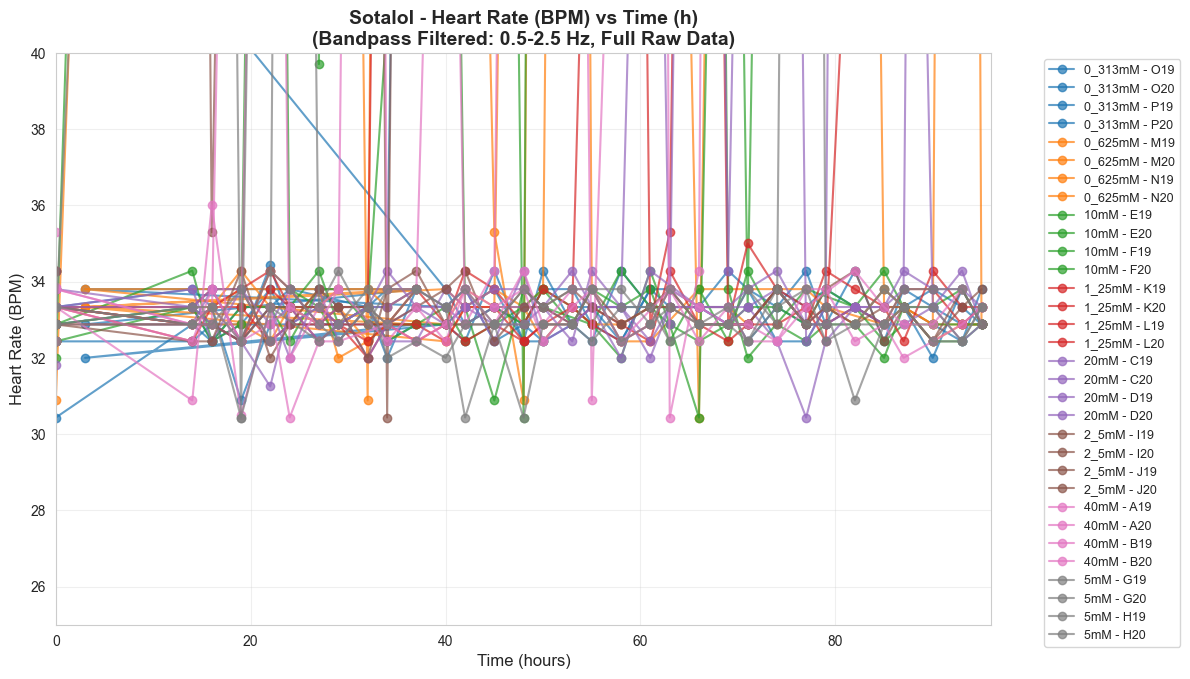

C:\Users\NoahB\AppData\Local\Temp\ipykernel_39200\1371703816.py:117: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab10')


  💾 Saved: chlorpromazine_bpm_vs_time_filtered.png


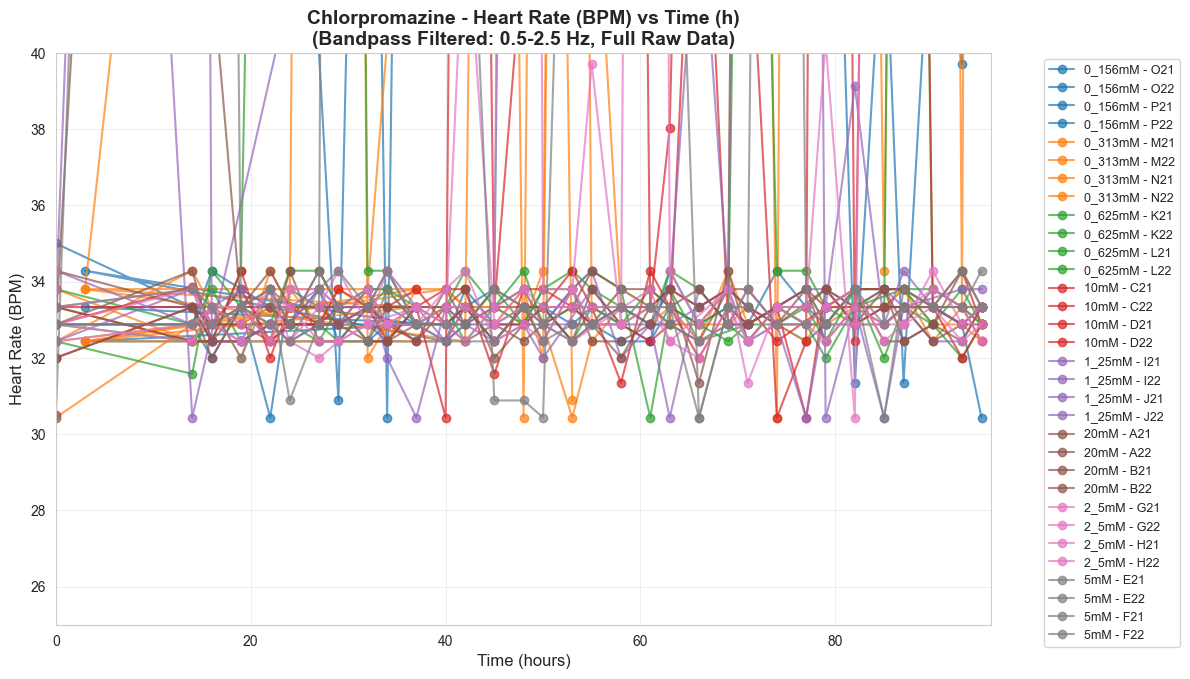

C:\Users\NoahB\AppData\Local\Temp\ipykernel_39200\1371703816.py:117: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab10')


  💾 Saved: amiodarone_bpm_vs_time_filtered.png


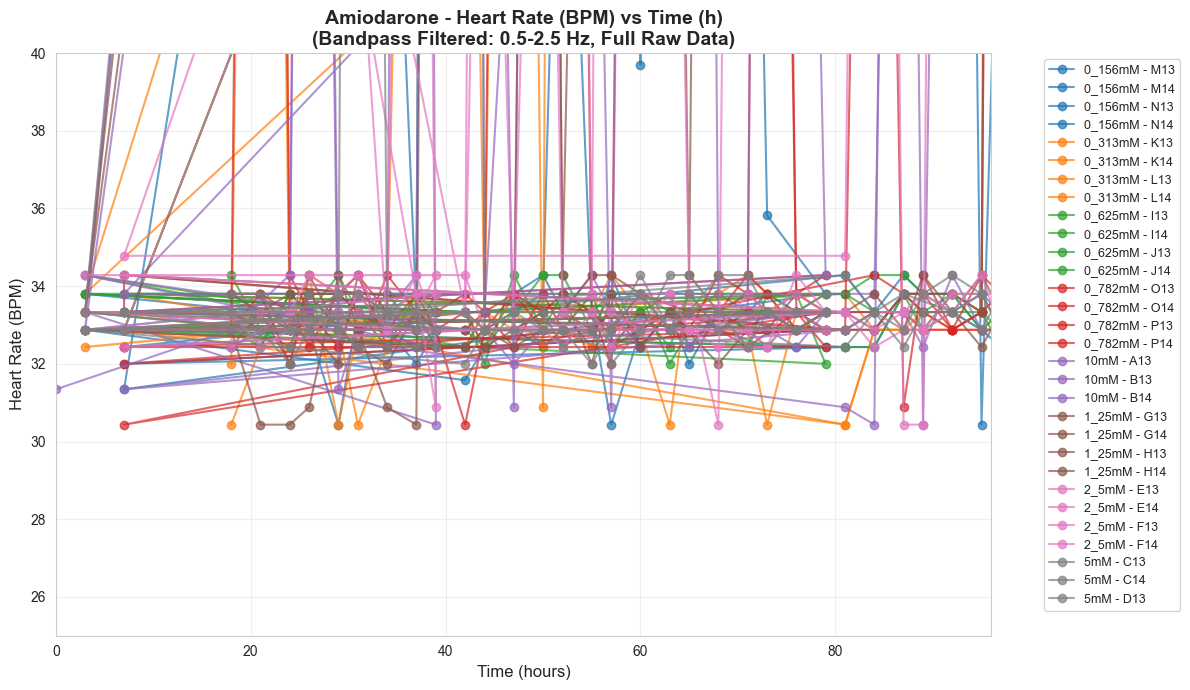

C:\Users\NoahB\AppData\Local\Temp\ipykernel_39200\1371703816.py:117: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab10')


  💾 Saved: ibrutinib_bpm_vs_time_filtered.png


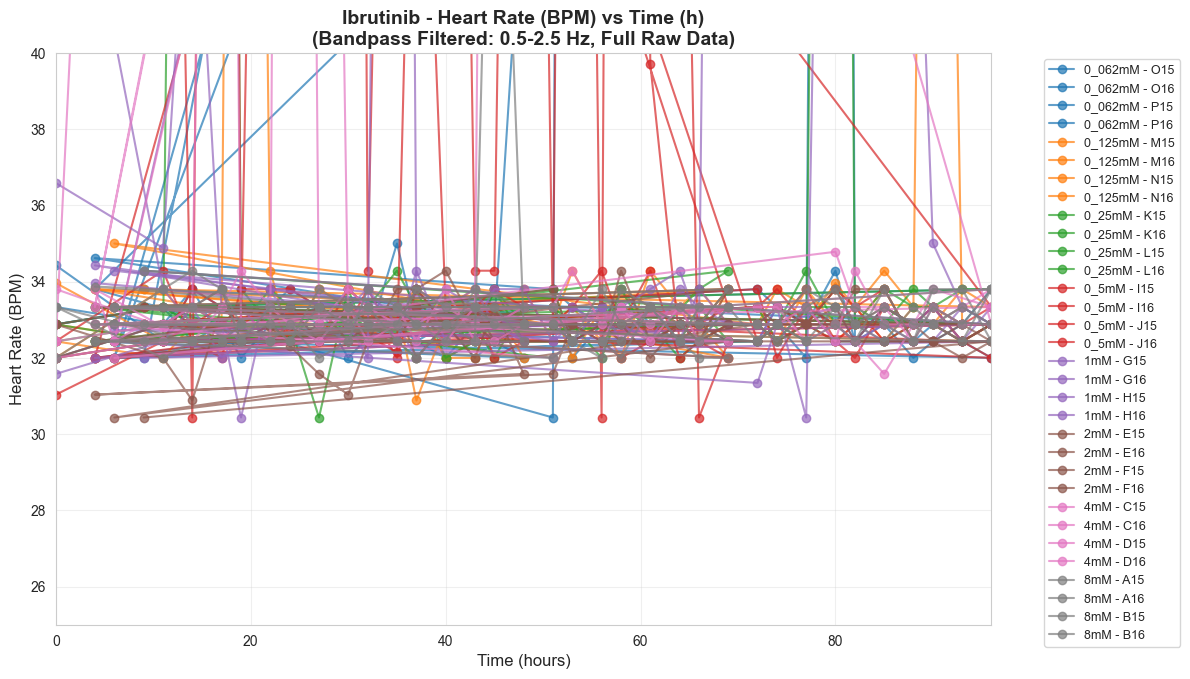

C:\Users\NoahB\AppData\Local\Temp\ipykernel_39200\1371703816.py:117: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab10')


  💾 Saved: vandetanib_bpm_vs_time_filtered.png


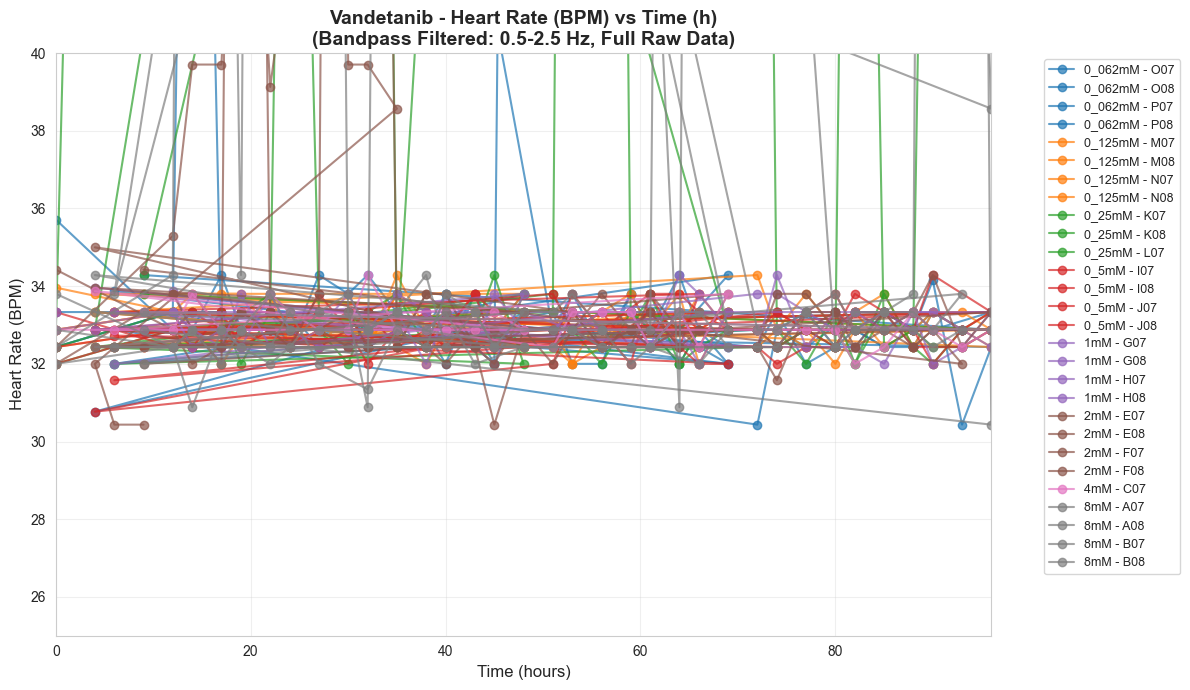

C:\Users\NoahB\AppData\Local\Temp\ipykernel_39200\1371703816.py:117: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab10')


  💾 Saved: bortezomib_bpm_vs_time_filtered.png


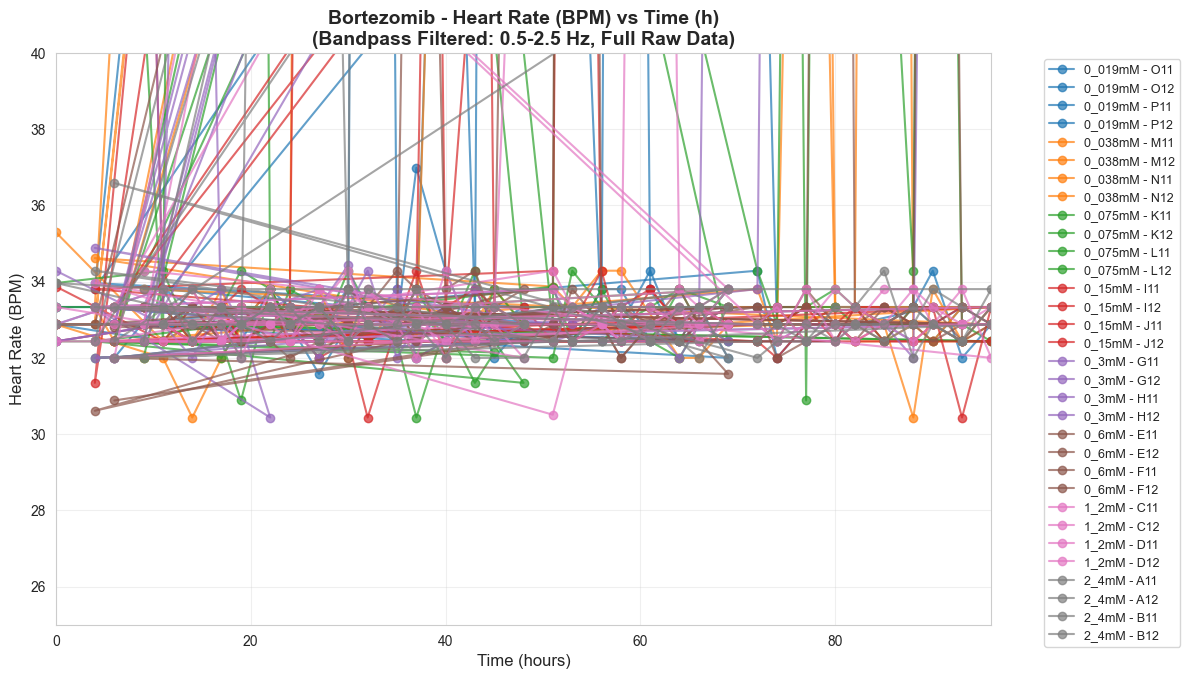

In [ ]:
# Plot BPM vs Time with Bandpass Filtering (0.5-2.5 Hz)
from scipy.fft import fft, ifft, fftfreq

def bandpass_filter_signal(time_s: np.ndarray, signal: np.ndarray, 
                           freq_band: Tuple[float, float] = (0.5, 2.5)) -> np.ndarray:
    """
    Apply bandpass filter in frequency domain and return cleaned signal via inverse FFT
    
    Args:
        time_s: Time array in seconds
        signal: Signal array
        freq_band: Tuple of (low_freq, high_freq) in Hz
        
    Returns:
        Filtered signal in time domain
    """
    if len(signal) < 4:
        return signal
    
    # Detrend and sort by time
    signal_detrended = signal - np.nanmean(signal)
    order = np.argsort(time_s)
    time_sorted = time_s[order]
    signal_sorted = signal_detrended[order]
    
    # Compute sampling rate
    diffs = np.diff(time_sorted)
    if len(diffs) == 0 or np.allclose(diffs, 0):
        return signal
    
    dt = np.median(diffs)
    if dt <= 0:
        return signal
    
    fs = 1.0 / dt
    n = len(signal_sorted)
    
    # FFT
    signal_fft = fft(signal_sorted)
    freqs = fftfreq(n, dt)
    
    # Create bandpass filter mask
    freq_mask = (np.abs(freqs) >= freq_band[0]) & (np.abs(freqs) <= freq_band[1])
    
    # Apply filter by zeroing out frequencies outside the band
    signal_fft_filtered = signal_fft.copy()
    signal_fft_filtered[~freq_mask] = 0
    
    # Inverse FFT to get cleaned signal
    signal_cleaned = np.real(ifft(signal_fft_filtered))
    
    return signal_cleaned

def collect_bpm_timepoints_filtered(drug_name, config):
    """Collect BPM using bandpass filtering on raw data (no row skipping)"""
    drug_folder = RELAXED_DIR / config["folder"]
    if not drug_folder.exists():
        return pd.DataFrame()
    records = []
    for concentration in config["concentrations"]:
        conc_dir = drug_folder / concentration
        if not conc_dir.exists():
            continue
        for csv_file in conc_dir.glob("*.csv"):
            hour = extract_hour_from_filename(csv_file.name)
            if hour is None:
                continue
            
            # Load data WITHOUT skipping rows - use raw data
            try:
                df = pd.read_csv(csv_file)
                if "time_s" not in df.columns or "amp1_vpp" not in df.columns:
                    continue
                df = df.dropna(subset=["time_s", "amp1_vpp"])
                if df.empty:
                    continue
            except Exception:
                continue
            
            well = get_well_name(csv_file.name)
            
            # Apply bandpass filter (0.5-2.5 Hz) and inverse FFT to clean data
            time_s = df["time_s"].values
            signal = df["amp1_vpp"].values
            signal_cleaned = bandpass_filter_signal(time_s, signal, freq_band=(0.5, 2.5))
            
            # Compute dominant frequency on cleaned signal
            freq_hz, _, _ = compute_dominant_frequency(time_s, signal_cleaned, freq_band=(0.5, 2.5))
            bpm = freq_hz * 60 if not np.isnan(freq_hz) else float("nan")
            
            records.append({
                "drug": drug_name,
                "concentration": concentration,
                "hour": hour,
                "well": well,
                "bpm": bpm
            })
    return pd.DataFrame(records)

# Collect all data with filtering
bpm_time_df_filtered_list = []
for drug_name, config in DRUG_CONFIG.items():
    df = collect_bpm_timepoints_filtered(drug_name, config)
    if not df.empty:
        bpm_time_df_filtered_list.append(df)
if bpm_time_df_filtered_list:
    bpm_time_df_filtered = pd.concat(bpm_time_df_filtered_list, ignore_index=True)
else:
    bpm_time_df_filtered = pd.DataFrame()

if not bpm_time_df_filtered.empty:
    print("Plotting BPM vs Time with Bandpass Filtering (0.5-2.5 Hz)...")
    # Plot for each drug/concentration/well
    for drug in bpm_time_df_filtered["drug"].unique():
        drug_df = bpm_time_df_filtered[bpm_time_df_filtered["drug"] == drug]
        plt.figure(figsize=(12, 7))
        color_map = cm.get_cmap('tab10')
        for i, (conc, conc_df) in enumerate(drug_df.groupby("concentration")):
            for well, well_df in conc_df.groupby("well"):
                plt.plot(well_df["hour"], well_df["bpm"], marker='o', linestyle='-',
                         label=f"{conc} - {well}", alpha=0.7, color=color_map(i % 10))
        plt.title(f"{drug.title()} - Heart Rate (BPM) vs Time (h)\n(Bandpass Filtered: 0.5-2.5 Hz, Full Raw Data)", 
                 fontsize=14, fontweight='bold')
        plt.xlabel("Time (hours)", fontsize=12)
        plt.ylabel("Heart Rate (BPM)", fontsize=12)
        plt.xlim(0, 96)
        plt.ylim(25, 40)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        save_path = OUTPUT_DIR / f"{drug}_bpm_vs_time_filtered.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  💾 Saved: {save_path.name}")
        plt.show()
else:
    print("No BPM/time data available for plotting.")